This notebook captures the second half od `scaling_laws_lr.ipynb` and `scaling_laws_bsz.ipynb`, without the experimentation, and just fits the final power laws for the oint optima.

In [1]:
# Import settings/
nb_settings_path = "./settings.py"
with open(nb_settings_path) as f:
    code = f.read()
    exec(code)

In [2]:
import os
import re
import math
import itertools
from typing import List
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize

import seaborn as sns

import statsmodels.api as sm

from utils import FORMAT_N, FORMAT_D, N_color_map, D_color_map, N_ticks, D_ticks
from utils_scaling_fit import plot_diagnostic, plot_diagnostic_1d, plot_diagnostic_2d, bootstrap_test_null
from utils_plotting import plot_hp_vs_ND_fix_other, plot_hp_vs_DN

def fit(df, y, x):
    y = df[y]
    X = sm.add_constant(df[x])
    return sm.OLS(y, X).fit()


In [3]:
SEQ_LEN = 4096

# full dataset
df_all = pd.read_csv('../data/loss_all_exps_post_annealing.csv')

# best HP
df_best_lr = pd.read_csv('../data/best_HPs/lr_min.csv')
df_best_gbsz = pd.read_csv('../data/best_HPs/gbsz_min.csv')
df_best_lr_gbsz = pd.read_csv('../data/best_HPs/lr_gbsz_min.csv')

# HP from quadratic fit
df_best_lr_gbsz_smooth = pd.read_csv('../data/best_HPs/lr_gbsz_min_smooth.csv')
df_best_lr_sliced = pd.read_csv('../data/best_HPs/lr_min_sliced.csv')
df_best_gbsz_sliced = pd.read_csv('../data/best_HPs/gbsz_min_sliced.csv')

# Load quadratic fits
fit_2d_lr_gbsz = pd.read_parquet('../data/quadratic_fits/fit_2d_lr_gbsz.parquet')
fit_2d_sliced_lr = pd.read_parquet('../data/quadratic_fits/fit_2d_sliced_lr.parquet')
fit_2d_sliced_gbsz = pd.read_parquet('../data/quadratic_fits/fit_2d_sliced_gbsz.parquet')


# Fit

In [4]:
# Data
df = df_best_lr_gbsz_smooth.copy()
df = df[df.N != 1_713_504_256].reset_index(drop=True)

In [5]:
# --- Fit models for lr and bsz ---

d_mean = np.log(df['D']).mean()
n_mean = np.log(df['N']).mean()

df['b'] = np.log(df['gbsz'])
df['l'] = np.log(df['lr'])
df['d'] = np.log(df['D'])
df['n'] = np.log(df['N'])

# center
for v in ['d','n']:
    df[v] -= df[v].mean()

m_lr = fit(df, y='l', x=['d','n'])
m_bsz = fit(df, y='b', x=['d','n'])

Learning rate

In [6]:
print(m_lr.summary())

                            OLS Regression Results                            
Dep. Variable:                      l   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.782
Method:                 Least Squares   F-statistic:                     80.07
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           4.67e-15
Time:                        10:36:39   Log-Likelihood:                0.74243
No. Observations:                  45   AIC:                             4.515
Df Residuals:                      42   BIC:                             9.935
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.9405      0.037   -188.980      0.0

In [7]:
## Can we drop n?
print(bootstrap_test_null(df,
    'l',
    ['d','n'],
    ['d']))
## Can we drop d?
print(bootstrap_test_null(df,
    'l',
    ['d','n'],
    ['n']))

(np.float64(9.209987798719835), np.float64(0.0))
(np.float64(0.5101276171884424), np.float64(0.0055))


In [8]:
# --- Recover Power Law equation ---

# centered-model coefficients
p = m_lr.params
b_const = p['const']
b_n     = p['n']
b_d     = p['d']

# centering
alpha = b_const - b_n * n_mean - b_d * d_mean
A = np.exp(alpha)

latex = rf"""
\hat{{\eta}}^\star | N,D = {A:.6f}\, N^{{{b_n:.2f}}} D^{{{b_d:.2f}}}
"""

print(latex)


\hat{\eta}^\star | N,D = 0.371396\, N^{-0.42} D^{0.09}



Batch size

In [9]:
print(m_bsz.summary())

                            OLS Regression Results                            
Dep. Variable:                      b   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     304.6
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           1.00e-25
Time:                        10:36:42   Log-Likelihood:                 20.103
No. Observations:                  45   AIC:                            -34.21
Df Residuals:                      42   BIC:                            -28.79
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.8961      0.024    204.986      0.0

In [10]:
## Can we drop n?
print(bootstrap_test_null(df,
    'b',
    ['d','n'],
    ['d']))
## Can we drop d?
print(bootstrap_test_null(df,
    'b',
    ['d','n'],
    ['n']))

(np.float64(1.1150738504395323), np.float64(0.0))
(np.float64(14.52457579422923), np.float64(0.0))


In [11]:
# --- Recover Power Law equation ---

# centered-model coefficients
p = m_bsz.params
b_const = p['const']
b_n     = p['n']
b_d     = p['d']

# centering
alpha = b_const - b_n * n_mean - b_d * d_mean
A = np.exp(alpha)

latex = rf"""
\hat{{b}}^\star | N,D = {A:.6f}\, N^{{{b_n:.2f}}} D^{{{b_d:.2f}}}
"""

print(latex)


\hat{b}^\star | N,D = 0.000099\, N^{0.15} D^{0.46}



# Plot model fits

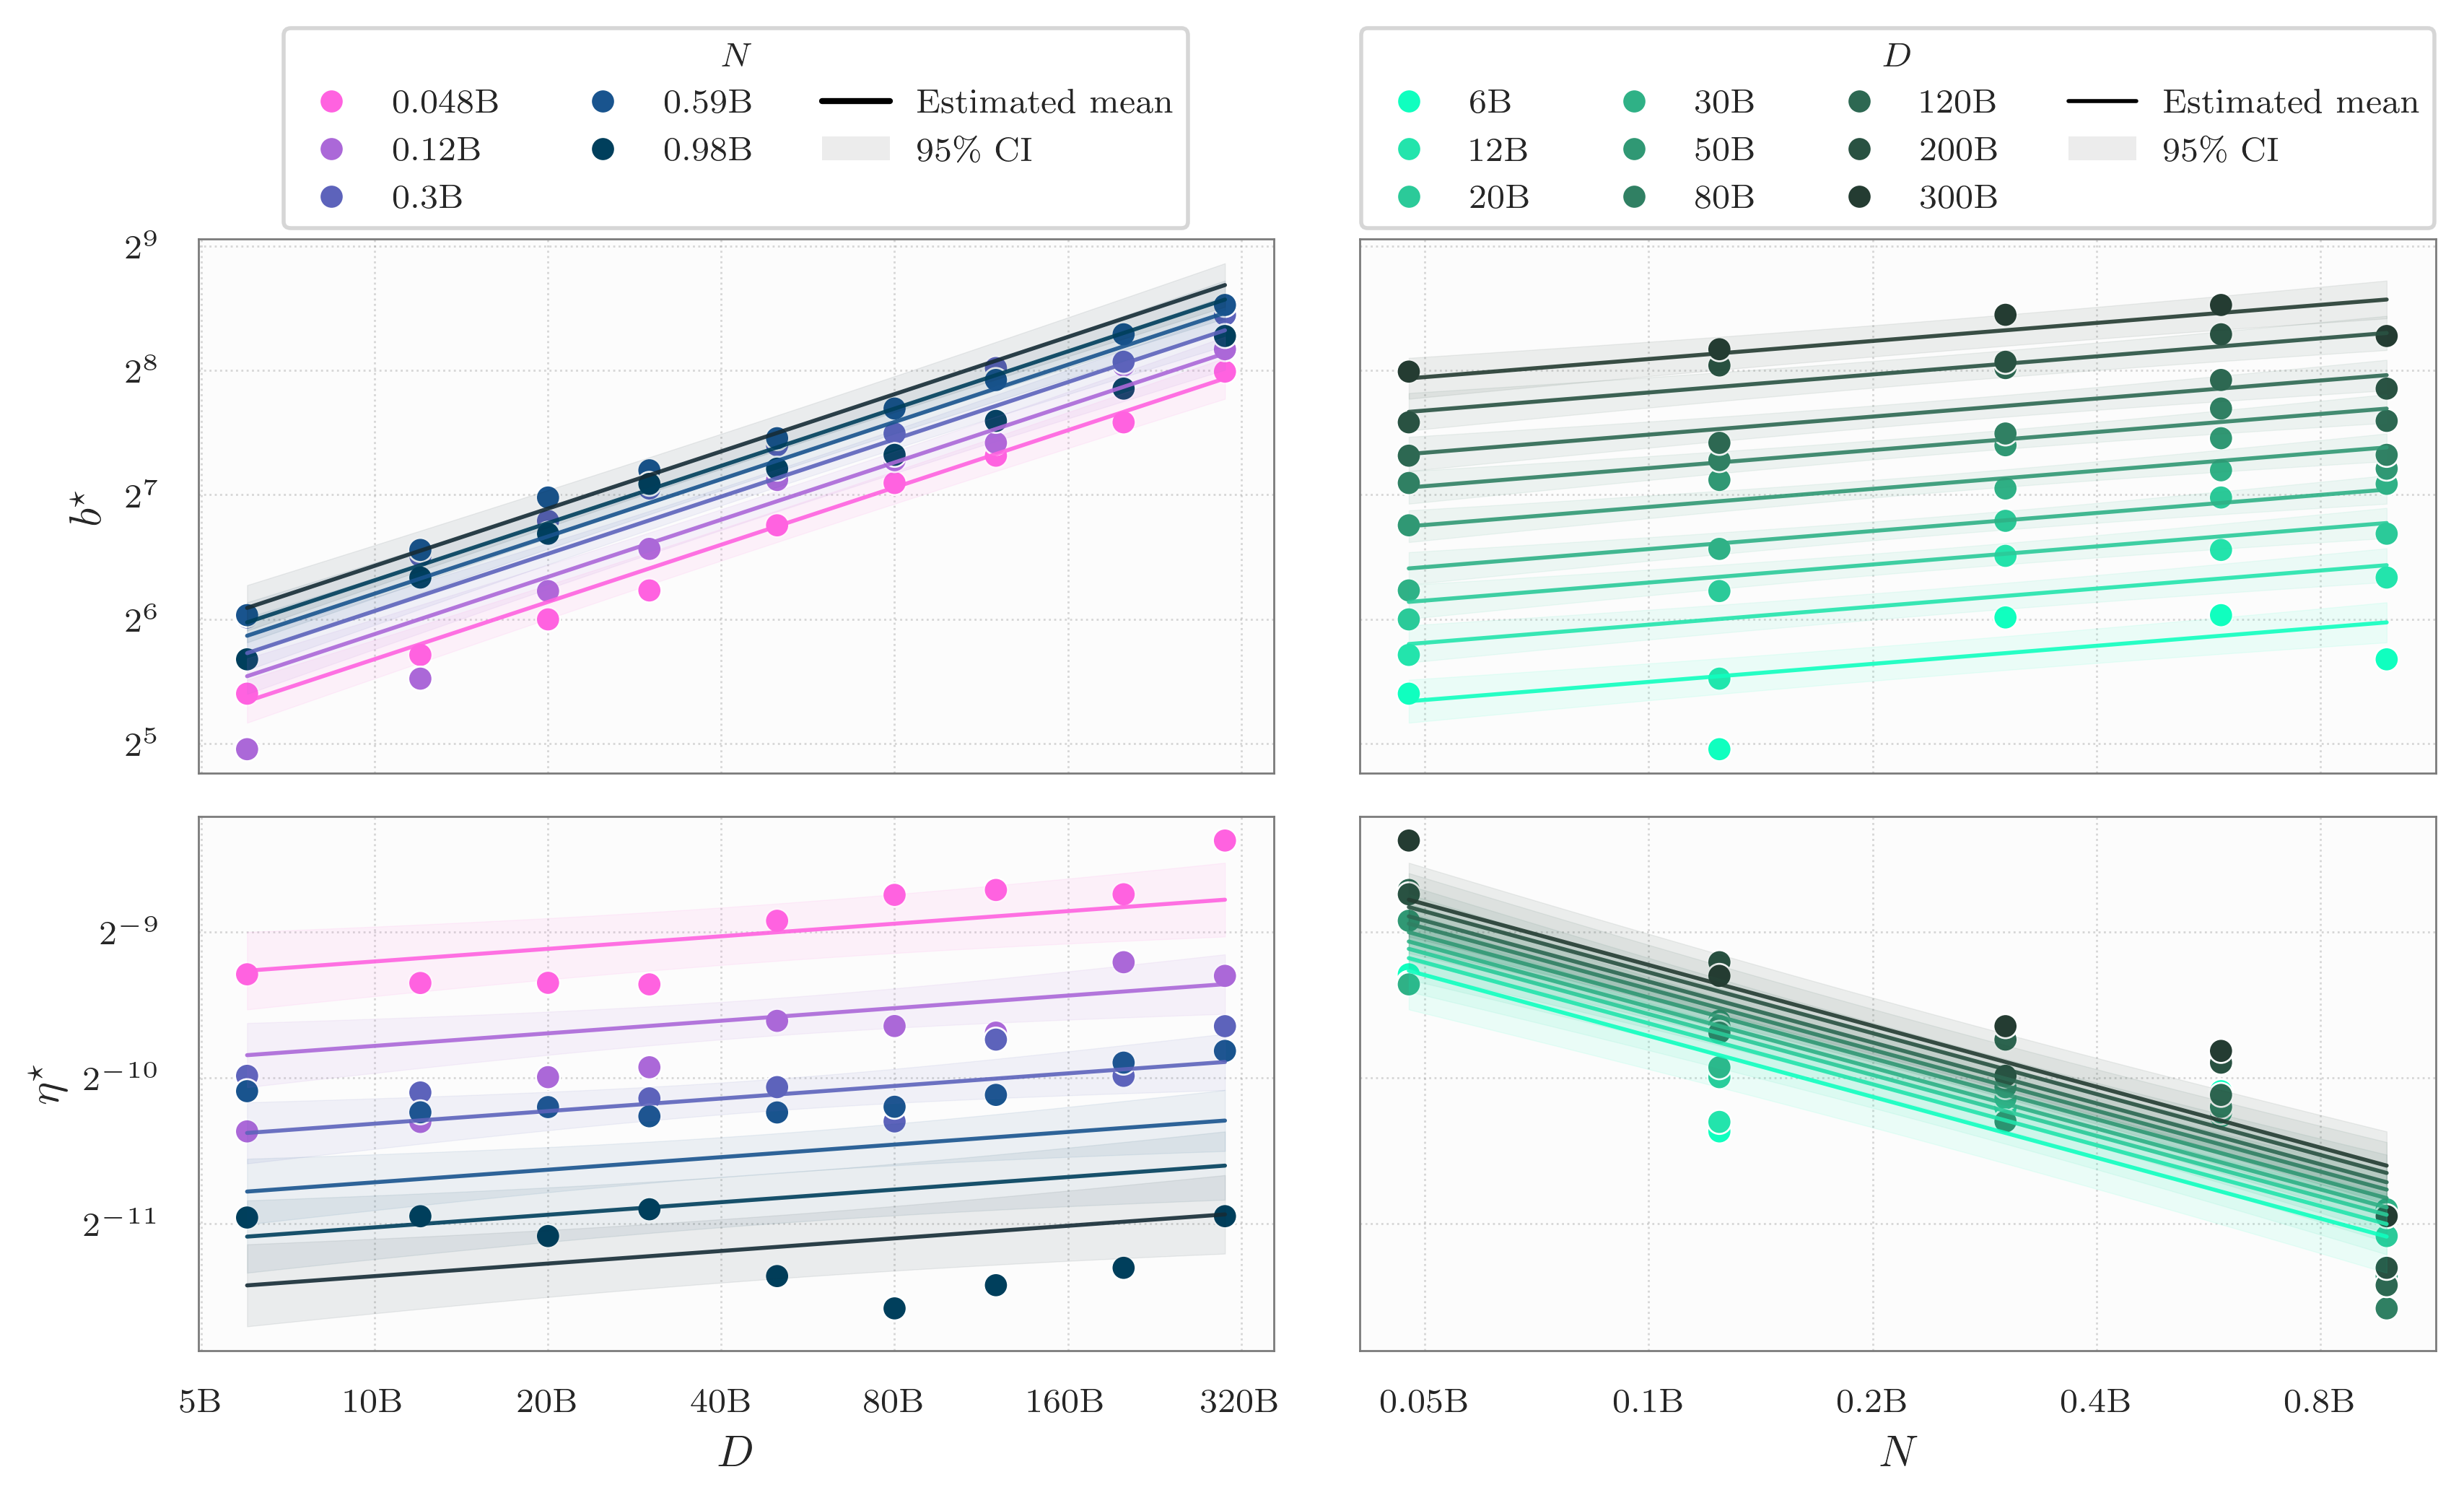

In [12]:
# -------------------------------------------------
# PLOT BSZ MODEL FIT
# -------------------------------------------------

df_plot = df.copy()
model = m_bsz

# recover mean for centering
d0 = np.log(df['D']).mean()
n0 = np.log(df['N']).mean()

D_grid = np.geomspace(df_plot['D'].min(), df_plot['D'].max(), 200)
N_grid = np.geomspace(df_plot['N'].min(), df_plot['N'].max(), 200)

# fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharey='row', sharex='col')
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 5),
    sharey="row",
    sharex="col",
    gridspec_kw={
        "hspace": 0.08,
        "wspace": 0.08,
    },
)

CONF_LEVEL = 0.95
CONF_LABEL = f"{100*CONF_LEVEL:.0f}\\% CI"

fit_line_kwargs = {
    "linewidth": 1,
    "alpha": 0.9,
}

ci_kwargs = {
    "alpha": 0.075,
    "linewidth": 0.25,
}

# =================================================
# LEFT: b vs D
# =================================================

sns.scatterplot(
    data=df_plot,
    x="D",
    y="gbsz",
    hue="N",
    palette=N_color_map,
    ax=axes[0,0],
)

for N, color in N_color_map.items():

    X = pd.DataFrame({
        "d": np.log(D_grid) - d0,
        "n": np.log(N) - n0,
    })
    X = sm.add_constant(X, has_constant="add")

    pred = m_bsz.get_prediction(X).summary_frame(alpha=1-CONF_LEVEL)
    mean = np.exp(pred["mean"])
    lo = np.exp(pred["mean_ci_lower"])
    hi = np.exp(pred["mean_ci_upper"])

    axes[0,0].plot(D_grid, mean, color=color, **fit_line_kwargs)
    axes[0,0].fill_between(D_grid, lo, hi, color=color, **ci_kwargs)
    
axes[0,0].set_xlabel(r"$D$")
axes[0,0].set_ylabel(r"$b^\star$")

# =================================================
# RIGHT: b vs N
# =================================================

sns.scatterplot(
    data=df_plot,
    x="N",
    y="gbsz",
    hue="D",
    palette=D_color_map,
    ax=axes[0,1],
)

for D, color in D_color_map.items():

    X = pd.DataFrame({
        "d": np.log(D) - d0,
        "n": np.log(N_grid) - n0,
    })
    X = sm.add_constant(X, has_constant="add")
    
    pred = m_bsz.get_prediction(X).summary_frame(alpha=1-CONF_LEVEL)
    mean = np.exp(pred["mean"])
    lo = np.exp(pred["mean_ci_lower"])
    hi = np.exp(pred["mean_ci_upper"])

    axes[0,1].plot(N_grid, mean, color=color, **fit_line_kwargs)
    axes[0,1].fill_between(N_grid, lo, hi, color=color, **ci_kwargs)

axes[0,1].set_xlabel(r"$N$")


# =================================================
# legends on top, centered over each subplot
# =================================================

# left legend
handles, labels = axes[0,0].get_legend_handles_labels()
labels = [FORMAT_N(float(l)) for l in labels]

handles += [
    Line2D([0], [0], color="black", lw=1.5),
    Patch(facecolor="gray", alpha=0.15, edgecolor="none"),
]
labels += [
    "Estimated mean",
    CONF_LABEL,
]

axes[0,0].legend(
    handles,
    labels,
    title=r"$N$",
    ncol=3,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    borderaxespad=0,
)

# right legend
handles, labels = axes[0,1].get_legend_handles_labels()
labels = [FORMAT_D(float(l)) for l in labels]

handles += [
    Line2D([0], [0], color="black", lw=1),
    Patch(facecolor="gray", alpha=0.15, edgecolor="none"),
]
labels += [
    "Estimated mean",
    CONF_LABEL,
]

axes[0,1].legend(
    handles,
    labels,
    title=r"$D$",
    ncol=4,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    borderaxespad=0,
)

# =================================================
# LEFT: lr vs D
# =================================================

sns.scatterplot(
    data=df_plot,
    x="D",
    y="lr",
    hue="N",
    palette=N_color_map,
    ax=axes[1,0],
)

for N, color in N_color_map.items():

    X = pd.DataFrame({
        "d": np.log(D_grid) - d0,
        "n": np.log(N) - n0,
    })
    X = sm.add_constant(X, has_constant="add")

    pred = m_lr.get_prediction(X).summary_frame(alpha=1-CONF_LEVEL)
    mean = np.exp(pred["mean"])
    lo = np.exp(pred["mean_ci_lower"])
    hi = np.exp(pred["mean_ci_upper"])

    axes[1,0].plot(D_grid, mean, color=color, **fit_line_kwargs)
    axes[1,0].fill_between(D_grid, lo, hi, color=color, **ci_kwargs)

axes[1,0].set_xlabel(r"$D$")
axes[1,0].set_ylabel(r"$\eta^\star$")

axes[1,0].get_legend().remove()

# =================================================
# RIGHT: lr vs N
# =================================================

sns.scatterplot(
    data=df_plot,
    x="N",
    y="lr",
    hue="D",
    palette=D_color_map,
    ax=axes[1,1],
)

for D, color in D_color_map.items():

    X = pd.DataFrame({
        "d": np.log(D) - d0,
        "n": np.log(N_grid) - n0,
    })
    X = sm.add_constant(X, has_constant="add")
    
    pred = m_lr.get_prediction(X).summary_frame(alpha=1-CONF_LEVEL)
    mean = np.exp(pred["mean"])
    lo = np.exp(pred["mean_ci_lower"])
    hi = np.exp(pred["mean_ci_upper"])

    axes[1,1].plot(N_grid, mean, color=color, **fit_line_kwargs)
    axes[1,1].fill_between(N_grid, lo, hi, color=color, **ci_kwargs)

axes[1,1].set_xlabel(r"$N$")
axes[1, 1].get_legend().remove()

# =================================================
# scales
# =================================================

axes[0,0].set_xscale("log")
axes[0,0].set_yscale("log", base=2)
axes[0,1].set_xscale("log")
axes[0,1].set_yscale("log", base=2)

axes[1,1].set_xscale("log")
axes[1,1].set_yscale("log", base=2)
axes[1,1].set_xscale("log")
axes[1,1].set_yscale("log", base=2)

# =================================================
# ticks
# =================================================

axes[0,0].set_xticks(D_ticks)
axes[0,0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: FORMAT_D(x)))
axes[0,1].set_xticks(N_ticks[:-1])
axes[0,1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: FORMAT_N(x)))

axes[1,0].set_xticks(D_ticks)
axes[1,0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: FORMAT_D(x)))
axes[1,1].set_xticks(N_ticks[:-1])
axes[1,1].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: FORMAT_N(x)))
    
# plt.tight_layout()
fig.savefig("../fig/joint_lr_bsz_scaling/lr_bsz_vs_ND_with_fit.pdf", dpi=400, bbox_inches='tight', pad_inches=0.02)
plt.show()

# Prediction accuracy on held-out 1.7B

In [13]:
# exogenous variables
N_new = 1_713_504_256
D_new = [30e9, 50e9, 80e9]

df_pred = pd.DataFrame({'D': D_new, 'N': D_new})
df_pred['N'] = N_new   # constant across D values

# centered covariates
df_pred['d'] = np.log(df_pred['D']) - d_mean
df_pred['n'] = np.log(df_pred['N']) - n_mean

X = df_pred[['d', 'n']]
X = sm.add_constant(X, has_constant='add')

In [14]:
# --- LR (lr) ---

pred = m_lr.get_prediction(X).summary_frame(alpha=0.05)

# mean prediction + prediction interval (for log-transformed hp)
df_pred['log_lr_pred'] = pred['mean']
df_pred['log_lr_pi_lo'] = pred['obs_ci_lower']
df_pred['log_lr_pi_hi'] = pred['obs_ci_upper']
del pred

df_pred['lr_pred'] = np.exp(df_pred['log_lr_pred'])
df_pred['lr_pi_lo'] = np.exp(df_pred['log_lr_pi_lo'])
df_pred['lr_pi_hi'] = np.exp(df_pred['log_lr_pi_hi'])
df_pred['lr_pi_pm'] = (df_pred['lr_pi_hi'] - df_pred['lr_pi_lo']) / 2

# --- BSZ (b) ---

pred = m_bsz.get_prediction(X).summary_frame(alpha=0.05)

# mean prediction + prediction interval (for log-transformed hp)
df_pred['log_b_pred'] = pred['mean']
df_pred['log_b_pi_lo'] = pred['obs_ci_lower']
df_pred['log_b_pi_hi'] = pred['obs_ci_upper']
del pred

df_pred['b_pred'] = np.exp(df_pred['log_b_pred'])
df_pred['b_pi_lo'] = np.exp(df_pred['log_b_pi_lo'])
df_pred['b_pi_hi'] = np.exp(df_pred['log_b_pi_hi'])
df_pred['b_pi_pm'] = (df_pred['b_pi_hi'] - df_pred['b_pi_lo']) / 2

display(df_pred[['N', 'D', 'lr_pred', 'lr_pi_pm', 'b_pred', 'b_pi_pm']])


,N,D,lr_pred,lr_pi_pm,b_pred,b_pi_pm
0,1713504256,3.000000e+10,0.000419,0.000228,142.862478,49.254122
1,1713504256,5.000000e+10,0.000438,0.000238,180.702271,62.209685
2,1713504256,8.000000e+10,0.000456,0.000248,224.312879,77.366560


In [15]:
# --- MSE + MAE + MAPE ---

ground_truth = df_best_lr_gbsz.copy()
ground_truth = ground_truth[
    (ground_truth.N == N_new) &
    (ground_truth.D.isin(D_new))
].reset_index(drop=True)

mse_lr = ((df_pred.lr_pred - ground_truth.lr) ** 2).mean()
mae_lr = abs(df_pred.lr_pred - ground_truth.lr).mean()
mape_lr = (abs(df_pred.lr_pred - ground_truth.lr) / abs(ground_truth.lr)).mean() * 100

mse_bsz = ((df_pred.b_pred - ground_truth.gbsz) ** 2).mean()
mae_bsz = abs(df_pred.b_pred - ground_truth.gbsz).mean()
mape_bsz = (abs(df_pred.b_pred - ground_truth.gbsz) / abs(ground_truth.gbsz)).mean() * 100

print(f"LR:  MSE={mse_lr:.3g}, \tMAE={mae_lr:.3g}, \tMAPE={mape_lr:.2f}%")
print(f"BSZ: MSE={mse_bsz:.3g}, \tMAE={mae_bsz:.3g}, \tMAPE={mape_bsz:.2f}%")

LR:  MSE=1.76e-08, 	MAE=0.000116, 	MAPE=37.00%
BSZ: MSE=1.33e+03, 	MAE=33.1, 	MAPE=21.72%


In [16]:
ANNOT_FONTSIZE = 12
TICK_FONTSIZE = 12
TITLE_FONTSIZE = 14
LABEL_FONTSIZE = 14
LEGEND_FONTSIZE = 12
CBAR_TITLE_FONTSIZE = 12

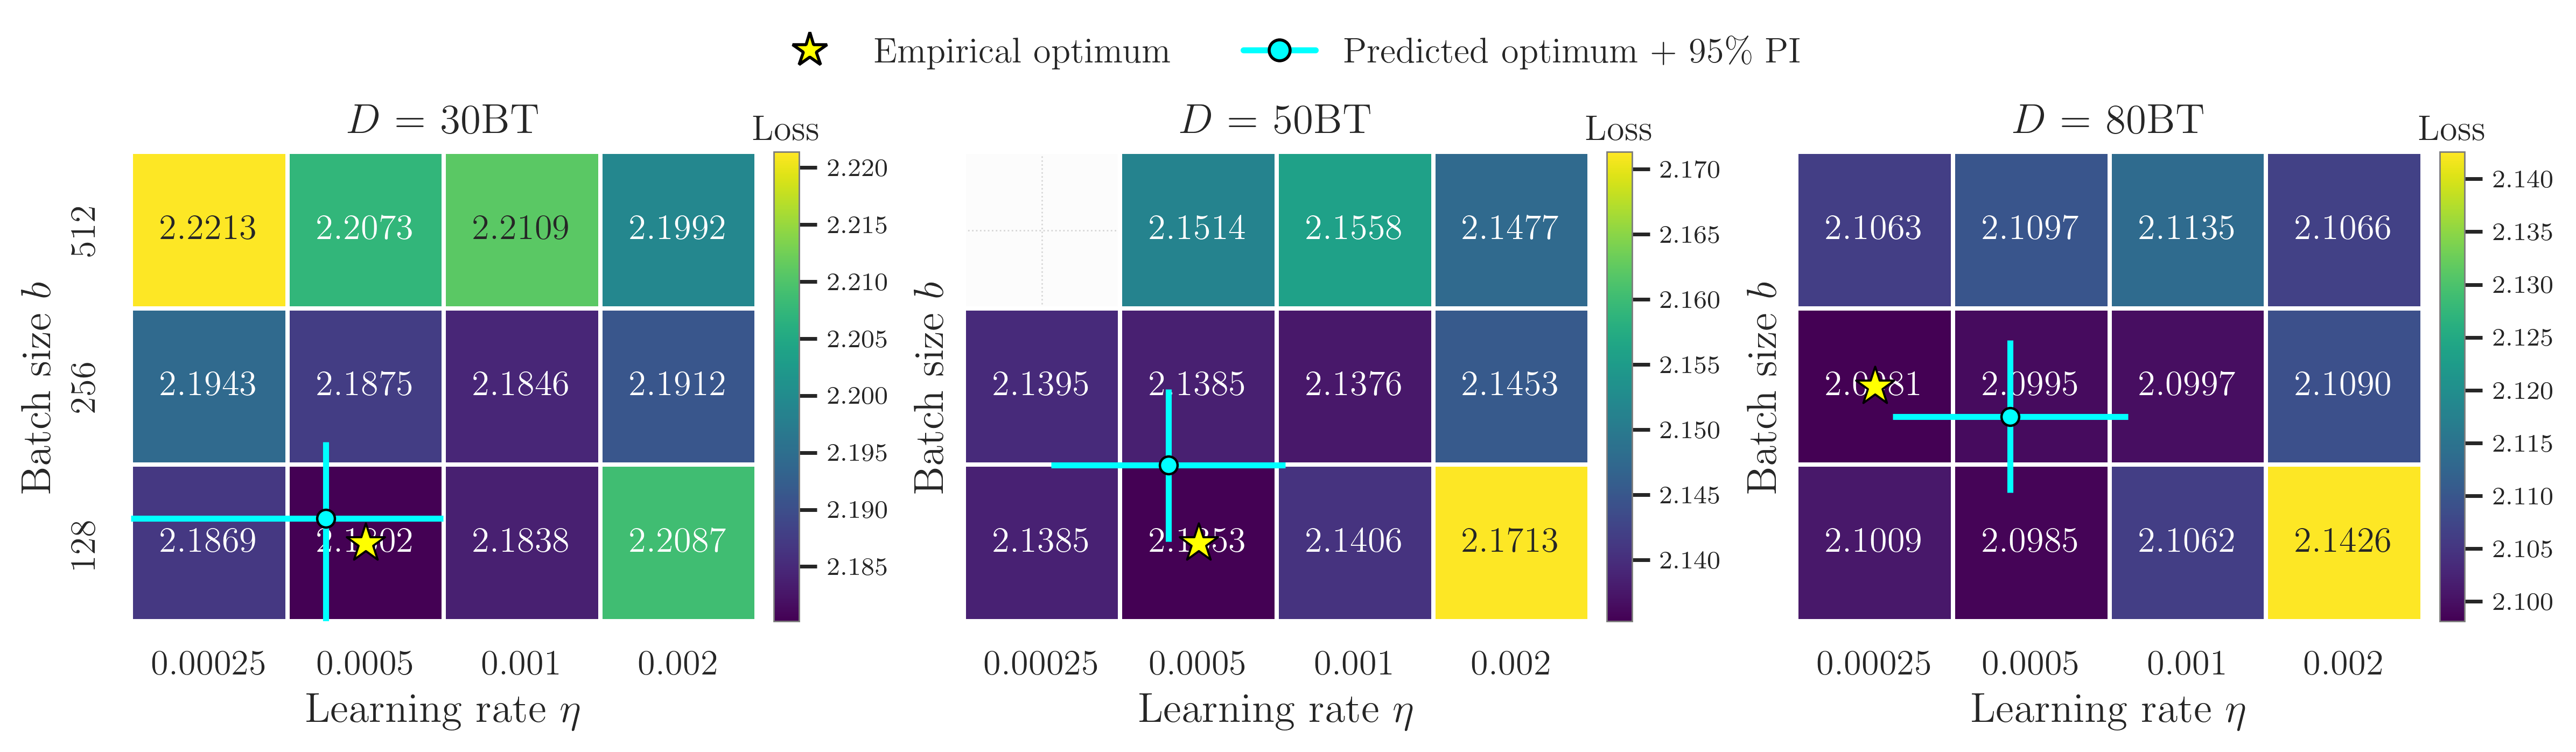

In [17]:
def heatmap_coord(value, values):
    """Map a value to heatmap cell-center coordinates."""
    return np.interp(np.log(value), np.log(values), np.arange(len(values))) + 0.5

def heatmap_boundary(value, values):
    """Map a value to heatmap coordinates, clipping to the heatmap boundaries."""
    if value <= values[0]:
        return 0.0
    if value >= values[-1]:
        return float(len(values))
    return np.interp(np.log(value), np.log(values), np.arange(len(values))) + 0.5

N = N_new
lrs = sorted(df_all[df_all.N == N]["lr"].unique())
bszs = sorted(df_all[df_all.N == N]["gbsz"].unique())

fig, axes = plt.subplots(1, len(D_new), figsize=(4 * len(D_new), 4), sharey=True)

if len(D_new) == 1:
    axes = [axes]

for ax, D in zip(axes, D_new):

    gt = df_all[(df_all.N == N) & (df_all.D == D)]

    pivot = gt.pivot_table(
        index="gbsz",
        columns="lr",
        values="loss",
        aggfunc="min",
    ).reindex(index=bszs, columns=lrs)

    hm = sns.heatmap(
        pivot,
        ax=ax,
        cmap="viridis",
        annot=True,
        annot_kws={"fontsize": ANNOT_FONTSIZE},
        fmt=".4f",
        cbar=False,
        square=True,
        linewidths=1.1,
        linecolor="white",
    )
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)
    cbar = fig.colorbar(hm.collections[0], cax=cax)
    cbar.ax.set_title("Loss", pad=4, fontsize=CBAR_TITLE_FONTSIZE)
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

    ax.invert_yaxis()

    # ==========================================================
    # empirical optimum (single best point)
    # ==========================================================

    vals = pivot.values

    if not np.all(np.isnan(vals)):
        y_emp, x_emp = np.unravel_index(np.nanargmin(vals), vals.shape)
        ax.scatter(x_emp + 0.5, y_emp + 0.5, marker="*", s=180, color="yellow", edgecolor="black", linewidth=0.7, zorder=10)

    # ==========================================================
    # predicted optimum + prediction intervals
    # ==========================================================

    pred = df_pred[df_pred.D == D].iloc[0]

    x = heatmap_coord(pred["lr_pred"], lrs)
    x_lo = heatmap_boundary(pred["lr_pi_lo"], lrs)
    x_hi = heatmap_boundary(pred["lr_pi_hi"], lrs)

    y = heatmap_coord(pred["b_pred"], bszs)
    y_lo = heatmap_boundary(pred["b_pi_lo"], bszs)
    y_hi = heatmap_boundary(pred["b_pi_hi"], bszs)

    # PI
    ax.hlines(y, x_lo, x_hi, color="cyan", linewidth=2, zorder=19)
    ax.vlines(x, y_lo, y_hi, color="cyan", linewidth=2, zorder=19)

    # Point prediction
    ax.scatter(x, y, marker="o", s=35, facecolors="cyan", edgecolors="black", linewidth=0.8, zorder=20, label="Point prediction")

    ax.set_title(f"$D$ = {FORMAT_D(D)}T", fontsize=TITLE_FONTSIZE)
    ax.set_xlabel(r"Learning rate $\eta$", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel(r"Batch size $b$", fontsize=LABEL_FONTSIZE)

# ==========================================================
# external legend
# ==========================================================

legend_handles = [
    Line2D([0], [0], marker="*", color="none", markerfacecolor="yellow", markeredgecolor="black", markersize=12, label="Empirical optimum"),
    Line2D([0], [0], marker="o", color="cyan", markerfacecolor="cyan", markeredgecolor="black", markersize=7, linewidth=2, label="Predicted optimum + 95\% PI"),
]

fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.92), ncol=2, frameon=False, fontsize=LEGEND_FONTSIZE)
plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig("../fig/joint_lr_bsz_scaling/predictions_1_7B_grid.pdf", dpi=400, bbox_inches="tight", pad_inches=0.02)

plt.show()

### Predict quadratic fit minima

In [18]:
# --- MSE + MAE + MAPE ---

D_new = [30e9, 50e9, 80e9]

ground_truth = df_best_lr_gbsz_smooth.copy()
ground_truth = ground_truth[
    (ground_truth.N == N_new) &
    (ground_truth.D.isin(D_new))
].reset_index(drop=True)

mse_lr = ((df_pred.lr_pred - ground_truth.lr) ** 2).mean()
mae_lr = abs(df_pred.lr_pred - ground_truth.lr).mean()
mape_lr = (abs(df_pred.lr_pred - ground_truth.lr) / abs(ground_truth.lr)).mean() * 100

mse_bsz = ((df_pred.b_pred - ground_truth.gbsz) ** 2).mean()
mae_bsz = abs(df_pred.b_pred - ground_truth.gbsz).mean()
mape_bsz = (abs(df_pred.b_pred - ground_truth.gbsz) / abs(ground_truth.gbsz)).mean() * 100

print(f"LR:  MSE={mse_lr:.3g}, \tMAE={mae_lr:.3g}, \tMAPE={mape_lr:.2f}%")
print(f"BSZ: MSE={mse_bsz:.3g}, \tMAE={mae_bsz:.3g}, \tMAPE={mape_bsz:.2f}%")

LR:  MSE=1.31e-08, 	MAE=9.17e-05, 	MAPE=28.44%
BSZ: MSE=479, 	MAE=19.1, 	MAPE=10.54%


In [19]:
# Loss observations across lr-bsz values for the 1.7B model
df_1_7B_all = df_all[((df_all.N == N_new) & (df_all.D.isin(D_new)))]
df_1_7B_all = df_1_7B_all.reset_index(drop=True)

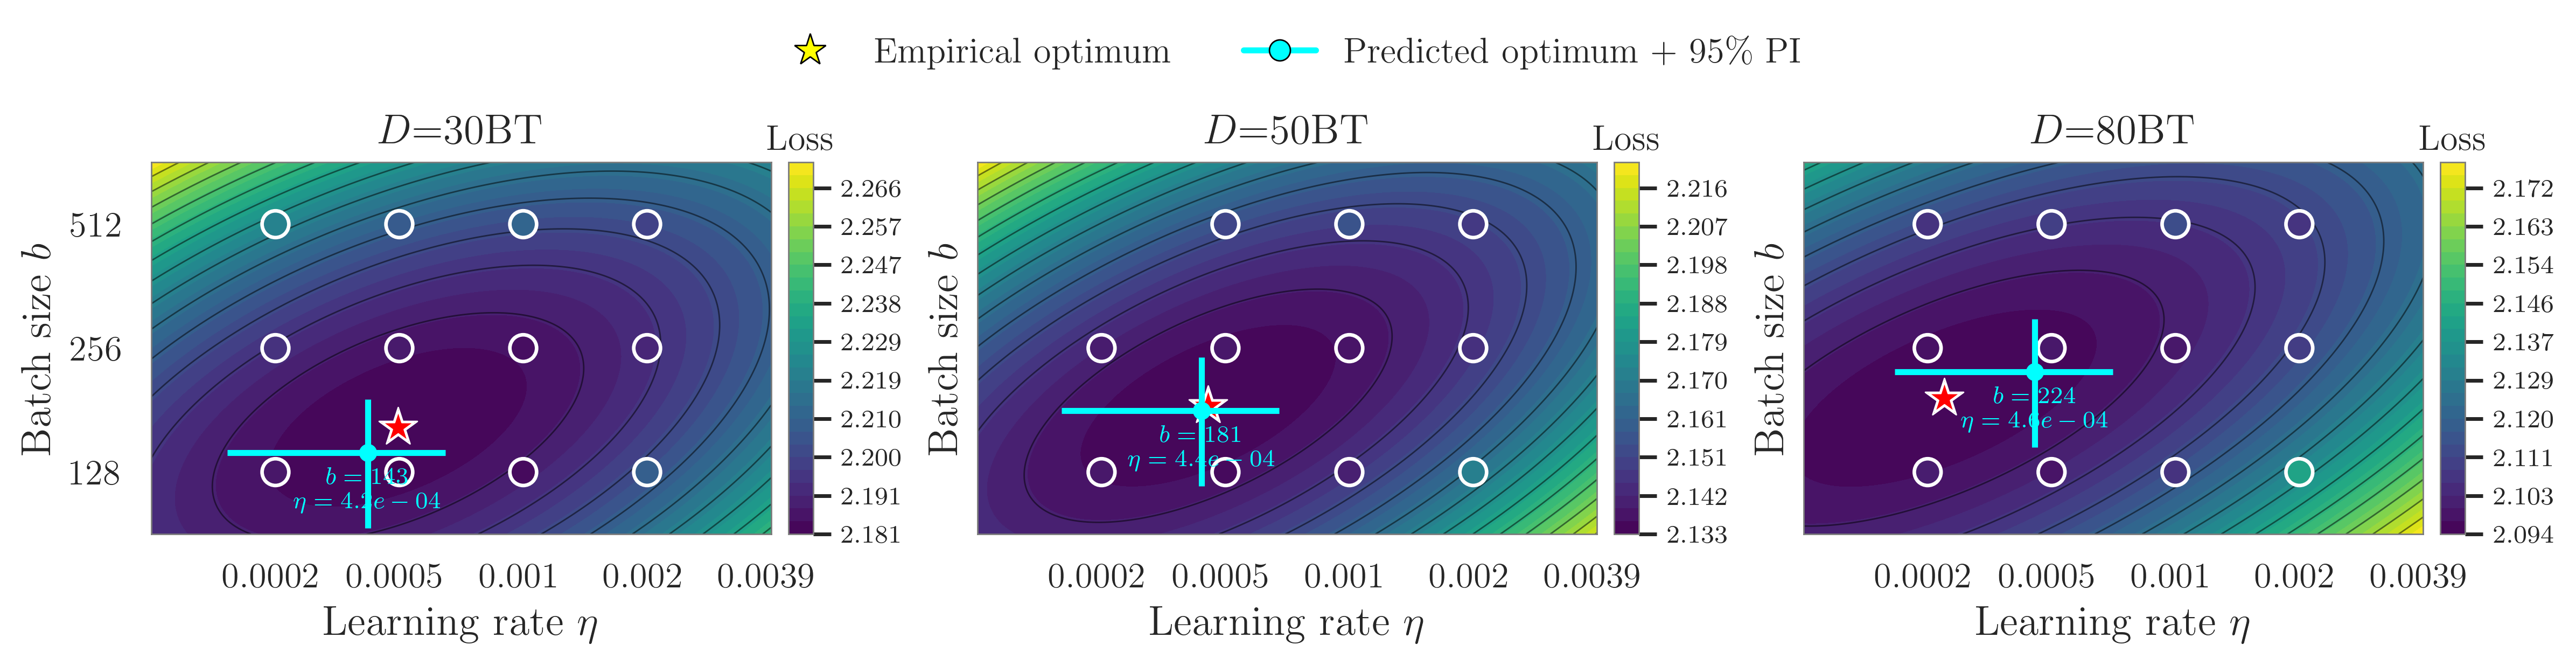

In [21]:
N = N_new

fig, axes = plt.subplots(1, len(D_new), figsize=(4 * len(D_new), 4), sharey=True)

lrs = np.sort(df_1_7B_all.lr.unique())
bszs = np.sort(df_1_7B_all.gbsz.unique())

if len(D_new) == 1:
    axes = [axes]

for ax, D in zip(axes, D_new):

    gt = df_1_7B_all[df_1_7B_all.D == D]

    fit_D = fit_2d_lr_gbsz[(fit_2d_lr_gbsz.N == N) & (fit_2d_lr_gbsz.D == D)].iloc[0]

    # ==========================================================
    # fitted quadratic surface
    # ==========================================================

    x_pad = 1.0
    y_pad = 0.5

    x_vals = np.linspace(np.log2(lrs.min()) - x_pad, np.log2(lrs.max()) + x_pad, 200)
    y_vals = np.linspace(np.log2(bszs.min()) - y_pad, np.log2(bszs.max()) + y_pad, 200)

    X, Y = np.meshgrid(x_vals, y_vals)

    a, b, c, d, e, f_coef = fit_D.coef

    Z = a + b * X + c * X**2 + d * Y + e * Y**2 + f_coef * X * Y

    vmin = Z.min()
    vmax = Z.max()

    norm = Normalize(vmin=vmin, vmax=vmax)

    cf = ax.contourf(X, Y, Z, levels=np.linspace(vmin, vmax, 30), cmap="viridis", norm=norm)

    ax.contour(X, Y, Z, levels=np.linspace(vmin, vmax, 15), colors="black", linewidths=0.5, alpha=0.5)

    # ==========================================================
    # measured points
    # ==========================================================

    ax.scatter(np.log2(gt.lr), np.log2(gt.gbsz), c=gt.loss, cmap="viridis", vmin=vmin, vmax=vmax, s=80, edgecolors="white", linewidths=1.2, zorder=3)

    # ==========================================================
    # fitted optimum
    # ==========================================================

    ax.scatter(np.log2(fit_D.lr_star), np.log2(fit_D.gbsz_star), marker="*", s=180, c="red", edgecolors="white", linewidths=0.5, zorder=4)

    # ==========================================================
    # predicted optimum + marginal prediction intervals
    # ==========================================================

    pred = df_pred[df_pred.D == D].iloc[0]

    lr_pred = pred["lr_pred"]
    b_pred = pred["b_pred"]

    x = np.log2(lr_pred)
    y = np.log2(b_pred)

    # Clip only to the plotted contour boundaries
    x_lo = max(np.log2(lr_pred - pred["lr_pi_pm"]), x_vals.min())
    x_hi = min(np.log2(lr_pred + pred["lr_pi_pm"]), x_vals.max())

    y_lo = max(np.log2(b_pred - pred["b_pi_pm"]), y_vals.min())
    y_hi = min(np.log2(b_pred + pred["b_pi_pm"]), y_vals.max())

    ax.hlines(y, x_lo, x_hi, color="cyan", linewidth=2, zorder=20)
    ax.vlines(x, y_lo, y_hi, color="cyan", linewidth=2, zorder=20)

    ax.scatter(x, y, s=25, color="cyan", zorder=21)

    ax.text(x, y - 0.12, rf"$b={b_pred:.0f}$" "\n" rf"$\eta={lr_pred:.1e}$", ha="center", va="top", fontsize=8, color="cyan", zorder=22)

    # ==========================================================
    # fitted quadratic optimum
    # ==========================================================

    ax.scatter(np.log2(fit_D.lr_star), np.log2(fit_D.gbsz_star), marker="*", s=120, c="red", edgecolors="white", linewidths=0.5, zorder=6)

    # ==========================================================
    # axes
    # ==========================================================

    xticks = np.arange(np.floor(x_vals.min()), np.ceil(x_vals.max()))
    yticks = np.arange(np.floor(y_vals.min()), np.ceil(y_vals.max()))

    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_xticklabels([f"{2**x:.4f}".rstrip("0").rstrip(".") for x in xticks])
    ax.set_yticklabels([f"{2**y:.0f}" for y in yticks])
    ax.set_xlim(x_vals.min(), x_vals.max())
    ax.set_ylim(y_vals.min(), y_vals.max())
    ax.set_aspect("equal")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)
    cbar = fig.colorbar(cf, cax=cax)
    cbar.ax.set_title("Loss", pad=4, fontsize=CBAR_TITLE_FONTSIZE)
    ax.set_xticklabels([f"{2**x:.4f}".rstrip("0").rstrip(".") for x in xticks])
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

    ax.set_title(f"$D$={FORMAT_D(D)}T", fontsize=TITLE_FONTSIZE)
    ax.set_xlabel(r"Learning rate $\eta$", fontsize=LABEL_FONTSIZE)
    ax.set_ylabel(r"Batch size $b$", fontsize=LABEL_FONTSIZE)


# ==========================================================
# external legend
# ==========================================================

legend_handles = [
    Line2D([0], [0], marker="*", color="none", markerfacecolor="yellow", markeredgecolor="black", markersize=11, markeredgewidth=0.5, label="Empirical optimum"),
    Line2D([0], [0], marker="o", color="cyan", markerfacecolor="cyan", markeredgecolor="black", markersize=7, markeredgewidth=0.5, linewidth=2, label="Predicted optimum + 95\% PI"),
]

fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.85), ncol=2, frameon=False, fontsize=LEGEND_FONTSIZE)
plt.tight_layout(rect=[0, 0, 1, 0.9])

fig.savefig("../fig/joint_lr_bsz_scaling/predictions_1_7B_contour.pdf", dpi=400, bbox_inches="tight", pad_inches=0.02)

plt.show()